In [8]:
from typing import Optional

from dotenv import load_dotenv
import os

from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph

load_dotenv(override=True)
checkpointer = InMemorySaver()

In [3]:
openai_key = os.getenv("OPENAI_KEY")

llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=openai_key,
    temperature=0.2,
    max_tokens=None,
    max_retries=2
)
llm2 = ChatOpenAI(
    model="gpt-4.1-nano",
    api_key=openai_key,
    temperature=0.2,
    max_tokens=None,
    max_retries=2
)

In [13]:
class TutorState(MessagesState):
    query: str
    context: Optional[str]
    answer: Optional[str]


def answer_query(state: TutorState) -> dict:
    # Only send the previous 10 conversation messages to the LLM.
    previous_messages = state.get("messages", [])[-10:]

    system_prompt = """You are a CS tutor.
Help the user understand the Regex.
Use the supplied context if it is relevant.
"""

    if state.get("context"):
        system_prompt += f"\nContext:\n{state['context']}"

    messages = [
        SystemMessage(content=system_prompt),
        *previous_messages,
        HumanMessage(content=state["query"]),
    ]

    response = llm.invoke(messages)

    return {
        "messages": [
            HumanMessage(content=state["query"]),
            AIMessage(content=response.content),
        ],
        "answer": response.content,
    }


builder = StateGraph(TutorState)

builder.add_node("answer_query", answer_query)

builder.add_edge(START, "answer_query")
builder.add_edge("answer_query", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

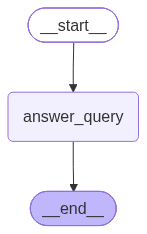

In [10]:
graph

In [14]:


result = graph.invoke(
    {
        "query": "What is recursion?",
        "context": "The student is learning Python functions.",
    },
    config={
        "configurable": {
            "thread_id": "student-123",
        }
    },
)

print(result["answer"])

Recursion is a programming technique where a function calls itself in order to solve a problem. This approach is often used to break down complex problems into simpler sub-problems. A recursive function typically has two main components:

1. **Base Case**: This is the condition under which the function stops calling itself. It prevents infinite recursion and allows the function to return a value.

2. **Recursive Case**: This is where the function calls itself with modified arguments, moving towards the base case.

Here's a simple example in Python to illustrate recursion:

```python
def factorial(n):
    # Base case: if n is 0 or 1, return 1
    if n == 0 or n == 1:
        return 1
    # Recursive case: n times the factorial of (n-1)
    else:
        return n * factorial(n - 1)

print(factorial(5))  # Output: 120
```

In this example, the `factorial` function calculates the factorial of a number `n`. The base case is when `n` is 0 or 1, at which point it returns 1. The recursive case

In [17]:
result["messages"]

[HumanMessage(content='What is recursion?', additional_kwargs={}, response_metadata={}, id='225d2e80-976a-494c-9c9b-e5026af2463d'),
 AIMessage(content="Recursion is a programming technique where a function calls itself in order to solve a problem. This approach is often used to break down complex problems into simpler sub-problems. A recursive function typically has two main components:\n\n1. **Base Case**: This is the condition under which the function stops calling itself. It prevents infinite recursion and allows the function to return a value.\n\n2. **Recursive Case**: This is where the function calls itself with modified arguments, moving towards the base case.\n\nHere's a simple example in Python to illustrate recursion:\n\n```python\ndef factorial(n):\n    # Base case: if n is 0 or 1, return 1\n    if n == 0 or n == 1:\n        return 1\n    # Recursive case: n times the factorial of (n-1)\n    else:\n        return n * factorial(n - 1)\n\nprint(factorial(5))  # Output: 120\n```

In [18]:
result = graph.invoke(
    {
        "query": "What is the guarantee that n will reduce to base value?",
        "context": "The student is learning Python functions.",
    },
    config={
        "configurable": {
            "thread_id": "student-123",
        }
    },
)

print(result["answer"])

The guarantee that `n` will reduce to the base value in a recursive function comes from the design of the recursive case and the logic of the problem being solved. Here are a few key points to ensure that the recursion will eventually reach the base case:

1. **Decrementing the Argument**: In the example of the factorial function, the recursive case calls the function with `n - 1`. Each time the function is called, `n` decreases by 1. This guarantees that after a finite number of calls, `n` will eventually reach the base case (0 or 1).

2. **Well-Defined Base Case**: The base case must be clearly defined and reachable. In the factorial example, we have a base case that handles when `n` is 0 or 1. If the base case is not well-defined or unreachable, it can lead to infinite recursion.

3. **Finite Input**: The input to the recursive function should be finite and should eventually lead to the base case. For example, if you call the factorial function with a negative number, it will not re

In [19]:
result["messages"]

[HumanMessage(content='What is recursion?', additional_kwargs={}, response_metadata={}, id='225d2e80-976a-494c-9c9b-e5026af2463d'),
 AIMessage(content="Recursion is a programming technique where a function calls itself in order to solve a problem. This approach is often used to break down complex problems into simpler sub-problems. A recursive function typically has two main components:\n\n1. **Base Case**: This is the condition under which the function stops calling itself. It prevents infinite recursion and allows the function to return a value.\n\n2. **Recursive Case**: This is where the function calls itself with modified arguments, moving towards the base case.\n\nHere's a simple example in Python to illustrate recursion:\n\n```python\ndef factorial(n):\n    # Base case: if n is 0 or 1, return 1\n    if n == 0 or n == 1:\n        return 1\n    # Recursive case: n times the factorial of (n-1)\n    else:\n        return n * factorial(n - 1)\n\nprint(factorial(5))  # Output: 120\n```